In [1]:
from ultralytics import YOLO
import matplotlib.pyplot as plt 
import cv2
import json
import numpy as np
from pathlib import Path

In [2]:
# Definizione path globali
classroom_id = 3

IMAGE_PATH = f"data/classroom_{classroom_id}.png"
MASK_PATH = f"mask/classroom_{classroom_id}_mask.png"
SEATS_JSON_PATH = f"mask/classroom_{classroom_id}_seats.json"
RESULTS_JSON_PATH = f"output/classroom_{classroom_id}_occupation_results.json"
MODEL_NAME = "yolo26x-seg.pt"

**Segmentation Test** 

Apply the segmentation model to an image and visualize the results.


image 1/1 /Users/andrea/Desktop/UNIVERSITÀ/CORSI/Economia-e-Gestione-delle-Imprese/EgiNB-Project/backend/data/classroom_3.png: 480x640 13 persons, 21 backpacks, 13 laptops, 341.8ms
Speed: 6.4ms preprocess, 341.8ms inference, 6.5ms postprocess per image at shape (1, 3, 480, 640)
Number of detections: 47


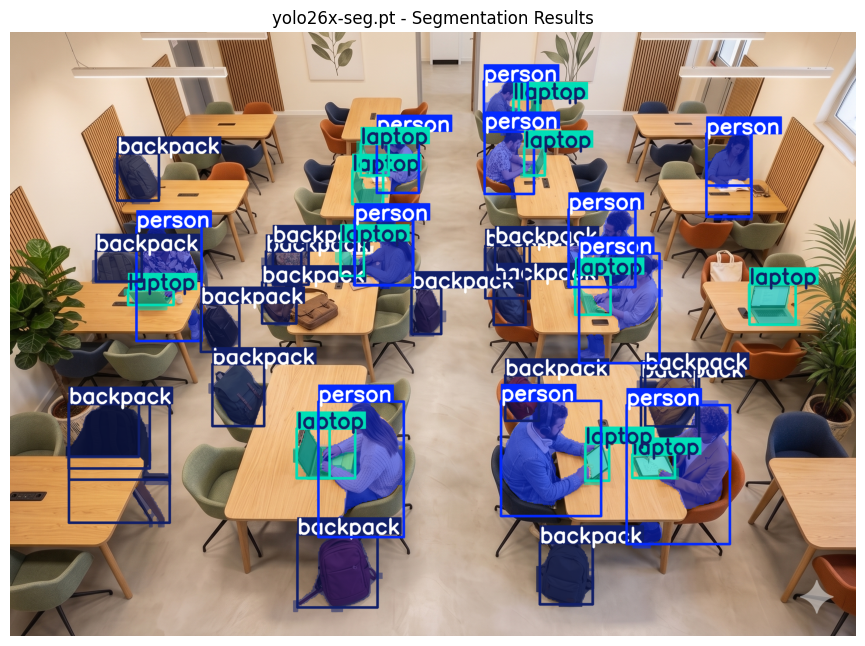

In [ ]:
# Load the model (if the model is not available, it will be downloaded automatically)

model = YOLO(f"./weights/{MODEL_NAME}")  # Load the model from the specified path

# get the results for the image
results = model.predict(IMAGE_PATH, conf=0.25, classes=[0, 63, 24])  # class 0 corresponds to 'person'  
result = results[0]

print(f"Number of detections: {len(result.boxes)}")
# plot the results
plt.figure(figsize=(15, 7))

annotated_img = result.plot(boxes=True, masks=True, labels=True, conf=False)  # Get the annotated image with masks only (no bounding boxes)
annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for correct color display in matplotlib

plt.title(f"{MODEL_NAME} - Segmentation Results")
plt.imshow(annotated_img_rgb)
plt.xlabel(f"Detections: {len(result.boxes)}")
plt.tight_layout()
plt.axis('off')  # Hide axes for better visualization
plt.show()


# Save the image using matplotlib
output_path = f"output/classroom_{classroom_id}_segmentation.png"
plt.imsave(output_path, annotated_img_rgb)


**Visualize the Mask**

Visualize the precomputed segmentation mask of the seats inside the scene.

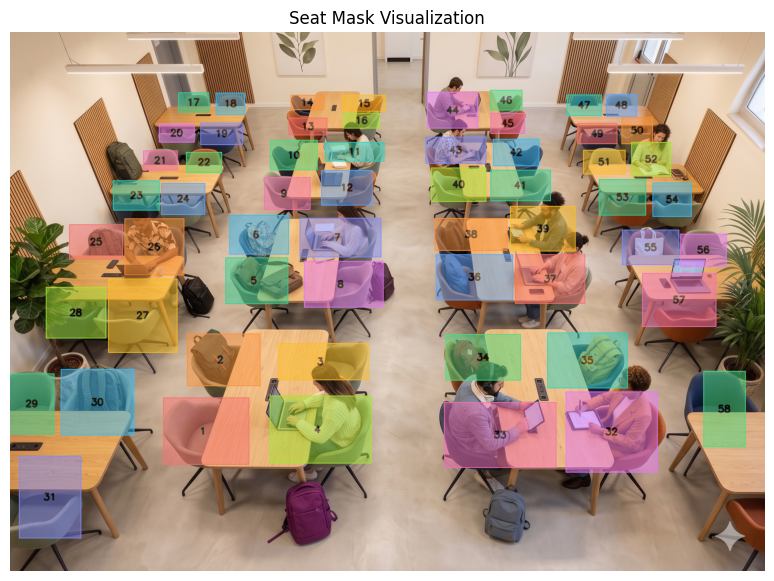

In [4]:
def visualize_mask(image_path: str, mask_path: str, json_path: str) -> np.ndarray:
    """
    Visualize the seat mask overlayed on the original image, with filled transparent rectangles.
    """
    
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Image not found: {image_path}")

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise FileNotFoundError(f"Mask not found: {mask_path}")

    with open(json_path, 'r') as f:
        seats_data = json.load(f)
    
    seats_list = seats_data['seats']
    
    # image overlay for rectangles background
    overlay = image.copy()
    # image overlay for rectangles borders 
    output = image.copy()
    
    for seat in seats_list:
        seat_color_hex = seat['color']
        seat_id = seat['id']
        mask_type = seat['type']
        
        # Convert HEX (#RRGGBB) to BGR (OpenCV format)
        r = int(seat_color_hex[1:3], 16)
        g = int(seat_color_hex[3:5], 16)
        b = int(seat_color_hex[5:7], 16)
        seat_color_bgr = (b, g, r)
        
        
        # Get the seat polygon bounding box coordinates based on the mask type
        if mask_type == 'rect':
            x_coords = [pt['x'] for pt in seat['points']]
            y_coords = [pt['y'] for pt in seat['points']]
            x_min, x_max = int(min(x_coords)), int(max(x_coords))
            y_min, y_max = int(min(y_coords)), int(max(y_coords))
            
            # Draw the filled rectangle on the overlay
            cv2.rectangle(overlay, (x_min, y_min), (x_max, y_max), seat_color_bgr, thickness=-1)
            # Draw the border on the output copy to keep it visible 
            cv2.rectangle(output, (x_min, y_min), (x_max, y_max), seat_color_bgr, thickness=2)
            # Add the seat ID inside and over the rectangle  
            cv2.putText(overlay, 
                    str(seat_id),
                    ((x_min // 2 + x_max // 2) - 20, (y_min // 2 + y_max // 2) + 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 
                    1, (0, 0, 0), 3, cv2.LINE_AA)
            
        if mask_type == 'freehand' or mask_type == 'poly': # polygonal freehand mask
            points = np.array([[pt['x'], pt['y']] for pt in seat['points']], dtype=np.int32)
            # Draw the filled polygon on the overlay
            cv2.fillPoly(overlay, [points], seat_color_bgr)
            # Draw the border on the output copy to keep it visible 
            cv2.polylines(output, [points], isClosed=True, color=seat_color_bgr, thickness=2)
            # Add the seat ID inside and over the polygon
            M = cv2.moments(points)
            if M['m00'] != 0:
                cX = int(M['m10'] / M['m00'])
                cY = int(M['m01'] / M['m00'])
                cv2.putText(overlay, 
                    str(seat_id),
                    (cX - 20, cY + 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 
                    1, (0, 0, 0), 3, cv2.LINE_AA)
        
        


    alpha = 0.5  # transparency factor (0.0 - fully transparent, 1.0 - fully opaque)
    # Blend the overlay with the output image using the specified alpha for transparency
    # formula: output * (1 - alpha) + overlay * alpha
    cv2.addWeighted(overlay, alpha, output, 1 - alpha, 0, output)
    
    return output

result = visualize_mask(
    image_path=IMAGE_PATH,
    mask_path=MASK_PATH,
    json_path=SEATS_JSON_PATH,
)

plt.figure(figsize=(15, 7))
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
plt.imshow(result_rgb)
# hide axes for better visualization
plt.axis('off')
plt.title("Seat Mask Visualization")
plt.show()


**Occupation Test**

The goal of this test is to determine the occupation status of each seat in the scene, following these steps:
1. For each seat, create a binary mask that corresponds to the seat's bounding box.
2. Use the `get_seat_occupation` function to analyze the overlap between the seat mask and the detections mask, which contains the detected objects in the scene.
3. If a segmentated object overlaps the seat above a certain threshold, the seat is considered occupied by that object (it can be a person, a bag, or any other item detected in the scene).
4. Store the occupation information for each seat in a dictionary or list for further analysis or visualization.

In [5]:
def get_seat_occupation(seat_mask, detections_mask, min_seat_overlap=0.05, min_person_overlap=0.05):
    """
    Determine if a seat is occupied based on the overlap between the seat mask and the detections mask.

    Args:
        seat_mask (np.ndarray): Binary mask of the seat area (1 for seat, 0 for background).
        detections_mask (np.ndarray): Mask with unique segment IDs for detected objects (0 for background).
        min_seat_overlap (float): Minimum required overlap ratio of the seat area covered by the detected segment to consider it as occupying the seat.
        min_person_overlap (float): Minimum required overlap ratio of the detected segment that overlaps with the seat to consider it as occupying
    
    Returns:
        dict or None: Information about the seat occupation if it's occupied, otherwise None.
    """
    
    occupation = detections_mask[seat_mask > 0]  # Get the values of the segments that overlap with the seat
    unique_ids, counts = np.unique(occupation, return_counts=True)
    
    # Filter out the background (ID 0)
    valid_idx = unique_ids > 0
    unique_ids = unique_ids[valid_idx]
    counts = counts[valid_idx]
    
    if len(unique_ids) == 0:
        return None  # No overlapping segment, seat is empty
    
    occupation_id = unique_ids[np.argmax(counts)]
    overlap_area = counts.max()
    
    # Calculate the area of the seat and the overlapping segment
    seat_area = np.sum(seat_mask > 0)
    occupation_area = np.sum(detections_mask == occupation_id)
    
    if seat_area == 0 or occupation_area == 0:
        return None  # Avoid division by zero
    
    # Calculate the overlap ratios
    seat_overlap_ratio = overlap_area / seat_area # how much of the seat is covered by the segmentated object
    occupation_overlap_ratio = overlap_area / occupation_area # how much of the segmentated object overlaps with the seat
    
    if seat_overlap_ratio >= min_seat_overlap or occupation_overlap_ratio >= min_person_overlap:
        return {
            "segment_id": occupation_id,
            "seat_overlap_ratio": seat_overlap_ratio,
            "occupation_overlap_ratio": occupation_overlap_ratio
        }  # Seat is occupied by the segment with this ID

    return None  # Seat is considered empty

In [6]:
# Get the results for the image
results = model.predict(IMAGE_PATH, conf=0.1)  
result = results[0]


detections_mask = np.zeros(result.orig_shape, dtype=np.uint8) # Initialize an empty mask to store segment IDs for detected objects
detections_info = {}  # Dictionary to store box, confidence, and class info

# create a mask where the pixels of each segmented object are filled with an unique ID corresponding to the segment index (starting from 1)
# Use zip to iterate over polygons and boxes simultaneously
for seg_id, (polygon, box) in enumerate(zip(result.masks.xy, result.boxes)):
    
    seg_id = seg_id + 1  # Start segment IDs from 1 to reserve 0 for background
    # 1. Draw the mask with a unique ID
    cv2.fillPoly(detections_mask, [polygon.astype(np.int32)],seg_id)
    
    # 2. Save the info by extracting the native values
    detections_info[seg_id] = {
        "box": box.xyxy[0].tolist(),         # Box coordinates [xmin, ymin, xmax, ymax]
        "confidence": box.conf.item(),       # Confidence (e.g., 0.85)
        "class": int(box.cls.item())         # Predicted class (e.g., 0 for person)
    }


# load the seats mask info
with open(SEATS_JSON_PATH, 'r') as f:
    seats_data = json.load(f)

seats_mask_size = (seats_data['image_size']['height'], seats_data['image_size']['width'])
seats_list = seats_data['seats']

if seats_mask_size != result.orig_shape:
    raise ValueError(f"Seat mask dimensions {seats_mask_size} do not match the original image dimensions {result.orig_shape}")

occupation_results = [] # Dictionary to store occupation info for each seat
cls_mapping = {0: "person", 63: "laptop", 24: "backpack"}

for seat in seats_list:
    seat_id = seat['id']
    # Get the bounding box coordinates for the seat
    x_coords = [pt['x'] for pt in seat['points']]
    y_coords = [pt['y'] for pt in seat['points']]
    x_min, x_max = int(min(x_coords)), int(max(x_coords))
    y_min, y_max = int(min(y_coords)), int(max(y_coords))
    
    # Create a binary mask for the current seat (1 for seat area, 0 for background)
    seat_mask = np.zeros(result.orig_shape, dtype=np.uint8)
    cv2.rectangle(seat_mask, (x_min, y_min), (x_max, y_max), 1, thickness=-1)
    
    seat_occupation_info = get_seat_occupation(seat_mask, detections_mask)
    
    if seat_occupation_info is not None:
        seat_occupation_result = {
            "seat_id": seat_id,
            "occupied": True,
            "seat_overlap_ratio": seat_occupation_info["seat_overlap_ratio"],
            "occupated_by_segment_id": cls_mapping.get(detections_info[seat_occupation_info["segment_id"]]["class"], "unknown")
        }
    else:
        seat_occupation_result = {
            "seat_id": seat_id,
            "occupied": False,
            "seat_overlap_ratio": 0.0,
            "occupated_by_segment_id": None
        }
    occupation_results.append(seat_occupation_result)
    
# save the occupation results in a json file
with open(RESULTS_JSON_PATH, 'w') as f:
    json.dump(occupation_results, f, indent=4)



image 1/1 /Users/andrea/Desktop/UNIVERSITÀ/CORSI/Economia-e-Gestione-delle-Imprese/EgiNB-Project/backend/data/classroom_3.png: 480x640 12 persons, 16 backpacks, 12 laptops, 388.8ms
Speed: 3.7ms preprocess, 388.8ms inference, 10.5ms postprocess per image at shape (1, 3, 480, 640)


**Visualization Test**

Use the occupation information obtained from the previous test to visualize the occupancy status of each seat in the scene.

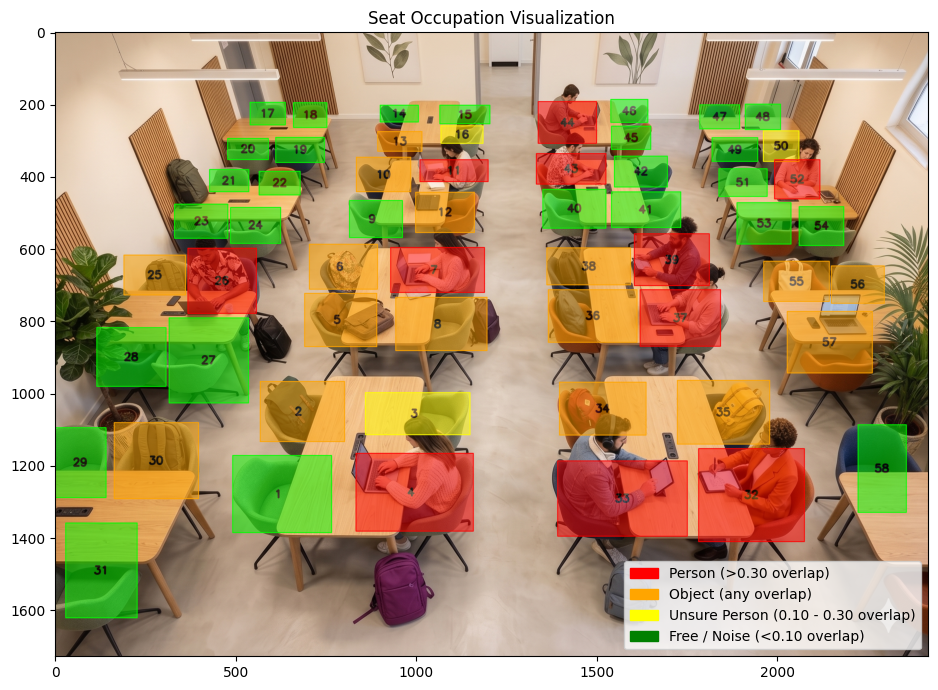

In [7]:
import matplotlib.patches as mpatches

with open(RESULTS_JSON_PATH, 'r') as f:
    occupation_results = json.load(f)

def visualize_occupation(image_path: str, json_path: str, occupation_results: list) -> np.ndarray:
    """
    Visualize the seat occupation status overlayed on the original image.
    Noise (<10%) -> Green
    Unsure (10% - 30%) -> Yellow
    Occupied Person (>30%) -> Red
    Occupied Object (any overlap) -> Orange
    """
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Image not found: {image_path}")

    with open(json_path, 'r') as f:
        seats_data = json.load(f)
    
    seats_list = seats_data['seats']
    
    # Create a dictionary for fast lookup of occupation status by seat_id
    occ_dict = {res['seat_id']: res for res in occupation_results}
    
    overlay = image.copy()
    output = image.copy()
    
    for seat in seats_list:
        seat_id = seat['id']
        
        # Get the bounding box coordinates
        x_coords = [pt['x'] for pt in seat['points']]
        y_coords = [pt['y'] for pt in seat['points']]
        x_min, x_max = int(min(x_coords)), int(max(x_coords))
        y_min, y_max = int(min(y_coords)), int(max(y_coords))
        
        # Determine color based on occupation status
        occ_info = occ_dict.get(seat_id)
        
        color_bgr = (0, 255, 0) # Default free (green)
        
        if occ_info:
            overlap = occ_info.get('seat_overlap_ratio', 0)
            seg = occ_info.get('occupated_by_segment_id')
            
            if seg in ['laptop', 'backpack']:
                color_bgr = (0, 165, 255)  # Occupied Object -> Orange in BGR
            else:
                if overlap < 0.10:
                    color_bgr = (0, 255, 0)  # Noise -> Free (green) in BGR
                elif 0.10 <= overlap <= 0.30:
                    color_bgr = (0, 255, 255)  # Unsure -> (yellow) in BGR
                elif overlap > 0.30:
                    color_bgr = (0, 0, 255)  # Occupied Person -> (red) in BGR
        
        # Draw the filled rectangle on the overlay
        cv2.rectangle(overlay, (x_min, y_min), (x_max, y_max), color_bgr, thickness=-1)
        # Draw the border on the output copy to keep it visible 
        cv2.rectangle(output, (x_min, y_min), (x_max, y_max), color_bgr, thickness=2)
        
        # Add the seat ID inside and over the rectangle  
        cv2.putText(overlay, 
                    str(seat_id),
                    ((x_min // 2 + x_max // 2) - 20, (y_min // 2 + y_max // 2) + 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 
                    1, (0, 0, 0), 3, cv2.LINE_AA)

    alpha = 0.5  # transparency factor
    # Blend the overlay with the output image
    cv2.addWeighted(overlay, alpha, output, 1 - alpha, 0, output)
    
    return output


result = visualize_occupation(
    image_path=IMAGE_PATH,
    json_path=SEATS_JSON_PATH,
    occupation_results=occupation_results
)

plt.figure(figsize=(15, 7))
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
plt.title("Seat Occupation Visualization")
plt.imshow(result_rgb)

# Create custom patches for the legend dynamically
red_patch = mpatches.Patch(color='red', label='Person (>0.30 overlap)')
orange_patch = mpatches.Patch(color='orange', label='Object (any overlap)')
yellow_patch = mpatches.Patch(color='yellow', label='Unsure Person (0.10 - 0.30 overlap)')
green_patch = mpatches.Patch(color='green', label='Free / Noise (<0.10 overlap)')

# Add the legend to the plot
plt.legend(handles=[red_patch, orange_patch, yellow_patch, green_patch], loc='lower right', bbox_to_anchor=(1.0, 0.0))

plt.tight_layout()
plt.show()